In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("global_poverty.csv")

In [3]:
data

,country,year,iso_code,population,gdp,gdp_per_capita,poverty_rate,gini_index,income_top1,income_top10,income_bottom50
0,Afghanistan,1980,AFG,13169313,1.532984e+10,1164.06,NaN,NaN,16.22,41.94,17.17
1,Afghanistan,1981,AFG,11937586,1.564534e+10,1310.60,NaN,NaN,16.22,41.94,17.17
2,Afghanistan,1982,AFG,10991380,1.598041e+10,1453.90,NaN,NaN,16.22,41.94,17.17
3,Afghanistan,1983,AFG,10917985,1.675533e+10,1534.65,NaN,NaN,16.22,41.94,17.17
4,Afghanistan,1984,AFG,11190222,1.707215e+10,1525.63,NaN,NaN,16.22,41.94,17.17
...,...,...,...,...,...,...,...,...,...,...,...
8950,Zimbabwe,2020,ZWE,15526887,2.317871e+10,1492.81,NaN,NaN,21.07,58.95,9.23
8951,Zimbabwe,2021,ZWE,15797220,2.514009e+10,1591.42,NaN,NaN,21.07,58.95,9.23
8952,Zimbabwe,2022,ZWE,16069061,2.590159e+10,1611.89,NaN,NaN,21.07,58.95,9.23
8953,Zimbabwe,2023,ZWE,16340829,NaN,NaN,NaN,NaN,21.07,58.95,9.23


In [4]:
misssing_count = data.isna().sum().sort_values(ascending=False)

In [5]:
missing_percent = (data.isnull().sum() / len(data)) * 100

print(missing_percent)

country             0.000000
year                0.000000
iso_code            0.000000
population          0.000000
gdp                21.440536
gdp_per_capita     21.440536
poverty_rate       75.354551
gini_index         75.354551
income_top1         7.537688
income_top10        7.537688
income_bottom50     7.537688
dtype: float64


### I checked if poverty_rate and gini_index have any usable data after having 75% of null values if there are a few thousand rows, i'll keep them

In [6]:
data["poverty_rate"].notnull().sum()

np.int64(2207)

In [7]:
data["gini_index"].notnull().sum()

np.int64(2207)

In [8]:
data_clean = data[(data["poverty_rate"].notnull()) & (data["gini_index"].notnull())]

In [9]:
data_clean

,country,year,iso_code,population,gdp,gdp_per_capita,poverty_rate,gini_index,income_top1,income_top10,income_bottom50
61,Albania,1996,ALB,3245680,1.246887e+10,3841.68,2.967841,27.010342,8.13,32.53,18.91
67,Albania,2002,ALB,3134095,1.703728e+10,5436.11,4.194722,31.738979,8.61,33.59,18.08
70,Albania,2005,ALB,3076156,2.056285e+10,6684.59,2.650218,30.595654,8.41,33.09,18.52
73,Albania,2008,ALB,2992933,2.500623e+10,8355.09,0.827308,29.984671,8.57,33.03,18.68
77,Albania,2012,ALB,2910003,2.781981e+10,9560.06,1.794590,28.960484,8.54,32.97,19.11
...,...,...,...,...,...,...,...,...,...,...,...
8900,Zambia,2015,ZMB,16399092,5.742395e+10,3501.65,67.892838,55.840749,22.24,60.83,7.38
8907,Zambia,2022,ZMB,20152935,6.846960e+10,3397.50,71.656150,51.484948,18.04,56.23,8.81
8941,Zimbabwe,2011,ZWE,13595421,1.955410e+10,1438.29,35.716999,43.153575,15.93,51.37,11.88
8947,Zimbabwe,2017,ZWE,14812484,2.557601e+10,1726.65,44.656873,44.337082,17.49,52.57,11.25


In [10]:
data_clean.info()

<class 'pandas.DataFrame'>
Index: 2207 entries, 61 to 8949
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          2207 non-null   str    
 1   year             2207 non-null   int64  
 2   iso_code         2207 non-null   str    
 3   population       2207 non-null   int64  
 4   gdp              2092 non-null   float64
 5   gdp_per_capita   2092 non-null   float64
 6   poverty_rate     2207 non-null   float64
 7   gini_index       2207 non-null   float64
 8   income_top1      2052 non-null   float64
 9   income_top10     2052 non-null   float64
 10  income_bottom50  2052 non-null   float64
dtypes: float64(7), int64(2), str(2)
memory usage: 206.9 KB


In [11]:
data_clean.describe()

,year,population,gdp,gdp_per_capita,poverty_rate,gini_index,income_top1,income_top10,income_bottom50
count,2207.000000,2.207000e+03,2.092000e+03,2092.000000,2207.000000,2207.000000,2052.000000,2052.000000,2052.000000
mean,2007.920707,5.250732e+07,9.318600e+11,19515.118475,11.906323,37.316677,15.476452,42.812286,15.965887
std,10.235511,1.543052e+08,2.550741e+12,16028.701346,19.825843,8.744634,6.187680,10.066802,5.265692
min,1980.000000,1.028900e+04,3.128536e+08,485.170000,0.000000,20.186578,3.410000,18.060000,3.270000
25%,2002.000000,4.570556e+06,3.524626e+10,6675.900000,0.249230,30.847608,10.550000,34.030000,11.325000
50%,2009.000000,1.043483e+07,1.902225e+11,15042.190000,1.697120,35.280752,14.205000,41.810000,16.360000
75%,2016.000000,4.638193e+07,7.449792e+11,29398.700000,14.765713,42.360680,19.830000,51.770000,20.190000
max,2024.000000,1.426437e+09,2.696600e+13,135490.380000,97.007811,71.050549,64.090000,80.290000,35.120000


In [12]:
print(f"My usable data after selecting rows with only present info is,{(data_clean.shape[0]/data.shape[0]*100)} %")

My usable data after selecting rows with only present info is,24.64544946957007 %


In [13]:
data.describe()

,year,population,gdp,gdp_per_capita,poverty_rate,gini_index,income_top1,income_top10,income_bottom50
count,8955.000000,8.955000e+03,7.035000e+03,7035.000000,2207.000000,2207.000000,8280.000000,8280.000000,8280.000000
mean,2002.000000,3.181992e+07,4.280270e+11,12993.551559,11.906323,37.316677,16.364193,45.501357,14.852360
std,12.987898,1.233910e+08,1.539946e+12,15062.870437,19.825843,8.744634,6.645195,10.374653,5.282871
min,1980.000000,5.010000e+02,1.642060e+08,361.190000,0.000000,20.186578,2.050000,16.690000,3.270000
25%,1991.000000,1.395996e+06,1.634127e+10,2653.850000,0.249230,30.847608,11.260000,36.330000,10.390000
50%,2002.000000,6.215816e+06,5.196766e+10,7552.390000,1.697120,35.280752,15.890000,47.100000,14.235000
75%,2013.000000,2.028627e+07,2.439440e+11,17795.405000,14.765713,42.360680,21.420000,54.070000,18.570000
max,2024.000000,1.450936e+09,2.696600e+13,163531.400000,97.007811,71.050549,64.090000,80.290000,36.500000


In [14]:
data_clean.describe()

,year,population,gdp,gdp_per_capita,poverty_rate,gini_index,income_top1,income_top10,income_bottom50
count,2207.000000,2.207000e+03,2.092000e+03,2092.000000,2207.000000,2207.000000,2052.000000,2052.000000,2052.000000
mean,2007.920707,5.250732e+07,9.318600e+11,19515.118475,11.906323,37.316677,15.476452,42.812286,15.965887
std,10.235511,1.543052e+08,2.550741e+12,16028.701346,19.825843,8.744634,6.187680,10.066802,5.265692
min,1980.000000,1.028900e+04,3.128536e+08,485.170000,0.000000,20.186578,3.410000,18.060000,3.270000
25%,2002.000000,4.570556e+06,3.524626e+10,6675.900000,0.249230,30.847608,10.550000,34.030000,11.325000
50%,2009.000000,1.043483e+07,1.902225e+11,15042.190000,1.697120,35.280752,14.205000,41.810000,16.360000
75%,2016.000000,4.638193e+07,7.449792e+11,29398.700000,14.765713,42.360680,19.830000,51.770000,20.190000
max,2024.000000,1.426437e+09,2.696600e+13,135490.380000,97.007811,71.050549,64.090000,80.290000,35.120000


### Implemented a Function to detect if the bias is present or not 

In [15]:
import pandas as pd

def check_bias(original_df, cleaned_df, threshold=0.5):
    """
    threshold = allowed % change (default = 10%)
    """

    # Select only numeric columns
    num_cols = original_df.select_dtypes(include=['number']).columns
    
    changed_cols = []
    
    for col in num_cols:
        # Drop NaNs for fair comparison
        orig = original_df[col].dropna()
        clean = cleaned_df[col].dropna()
        
        if len(orig) == 0 or len(clean) == 0:
            continue
        
        # Mean comparison
        mean_orig = orig.mean()
        mean_clean = clean.mean()
        
        # Range comparison
        range_orig = orig.max() - orig.min()
        range_clean = clean.max() - clean.min()
        
        # Avoid division by zero
        if mean_orig != 0:
            mean_change = abs(mean_clean - mean_orig) / abs(mean_orig)
        else:
            mean_change = 0
        
        if range_orig != 0:
            range_change = abs(range_clean - range_orig) / range_orig
        else:
            range_change = 0
        
        # Check if change exceeds threshold
        if mean_change > threshold or range_change > threshold:
            changed_cols.append(col)
    
    total_cols = len(num_cols)
    changed_percent = (len(changed_cols) / total_cols) * 100 if total_cols > 0 else 0
    
    # Bias decision
    bias = changed_percent > 30   # you can tune this
    
    return {
        "bias_detected": bias,
        "changed_columns_percent": round(changed_percent, 2),
        "changed_columns": changed_cols
    }

### We detected the bias 

In [16]:
check_bias(data, data_clean)

{'bias_detected': True,
 'changed_columns_percent': 33.33,
 'changed_columns': ['population', 'gdp', 'gdp_per_capita']}

### Due to high missing values in key variables (poverty_rate, gini_index), only ~24% of the dataset was retained.
A bias check revealed that ~33% of numerical features experienced distributional changes, indicating moderate sampling bias.
Therefore, insights should be interpreted with caution

### ❌ Global median imputation for gini_index is NOT logical

Because:

Inequality in India ≠ Norway
Different economies → completely different distribution

In [17]:
data_clean

,country,year,iso_code,population,gdp,gdp_per_capita,poverty_rate,gini_index,income_top1,income_top10,income_bottom50
61,Albania,1996,ALB,3245680,1.246887e+10,3841.68,2.967841,27.010342,8.13,32.53,18.91
67,Albania,2002,ALB,3134095,1.703728e+10,5436.11,4.194722,31.738979,8.61,33.59,18.08
70,Albania,2005,ALB,3076156,2.056285e+10,6684.59,2.650218,30.595654,8.41,33.09,18.52
73,Albania,2008,ALB,2992933,2.500623e+10,8355.09,0.827308,29.984671,8.57,33.03,18.68
77,Albania,2012,ALB,2910003,2.781981e+10,9560.06,1.794590,28.960484,8.54,32.97,19.11
...,...,...,...,...,...,...,...,...,...,...,...
8900,Zambia,2015,ZMB,16399092,5.742395e+10,3501.65,67.892838,55.840749,22.24,60.83,7.38
8907,Zambia,2022,ZMB,20152935,6.846960e+10,3397.50,71.656150,51.484948,18.04,56.23,8.81
8941,Zimbabwe,2011,ZWE,13595421,1.955410e+10,1438.29,35.716999,43.153575,15.93,51.37,11.88
8947,Zimbabwe,2017,ZWE,14812484,2.557601e+10,1726.65,44.656873,44.337082,17.49,52.57,11.25


In [18]:
data_clean.isna().sum()

country              0
year                 0
iso_code             0
population           0
gdp                115
gdp_per_capita     115
poverty_rate         0
gini_index           0
income_top1        155
income_top10       155
income_bottom50    155
dtype: int64

In [19]:
missing_percent = (data_clean.isnull().sum() / len(data_clean)) * 100

print(missing_percent)

country            0.000000
year               0.000000
iso_code           0.000000
population         0.000000
gdp                5.210693
gdp_per_capita     5.210693
poverty_rate       0.000000
gini_index         0.000000
income_top1        7.023108
income_top10       7.023108
income_bottom50    7.023108
dtype: float64


### For GDP missing value columns (~5%)

* I choose to fill thoose gaps by country wise median GDP as GDP of a country does not change that much.

* Same Goes for GDP per capita.

In [20]:
data_clean["gdp"] = data_clean.groupby("country")["gdp"].transform(lambda x: x.fillna(x.median()))

In [21]:
data_clean["gdp_per_capita"] = data_clean.groupby("country")["gdp_per_capita"].transform(lambda x: x.fillna(x.median()))

In [22]:
data_clean.isna().sum()

country              0
year                 0
iso_code             0
population           0
gdp                 52
gdp_per_capita      52
poverty_rate         0
gini_index           0
income_top1        155
income_top10       155
income_bottom50    155
dtype: int64

### Some countries have ALL values missing for that column, 👉 That’s why those 52 values remain

In [23]:
data_clean

,country,year,iso_code,population,gdp,gdp_per_capita,poverty_rate,gini_index,income_top1,income_top10,income_bottom50
61,Albania,1996,ALB,3245680,1.246887e+10,3841.68,2.967841,27.010342,8.13,32.53,18.91
67,Albania,2002,ALB,3134095,1.703728e+10,5436.11,4.194722,31.738979,8.61,33.59,18.08
70,Albania,2005,ALB,3076156,2.056285e+10,6684.59,2.650218,30.595654,8.41,33.09,18.52
73,Albania,2008,ALB,2992933,2.500623e+10,8355.09,0.827308,29.984671,8.57,33.03,18.68
77,Albania,2012,ALB,2910003,2.781981e+10,9560.06,1.794590,28.960484,8.54,32.97,19.11
...,...,...,...,...,...,...,...,...,...,...,...
8900,Zambia,2015,ZMB,16399092,5.742395e+10,3501.65,67.892838,55.840749,22.24,60.83,7.38
8907,Zambia,2022,ZMB,20152935,6.846960e+10,3397.50,71.656150,51.484948,18.04,56.23,8.81
8941,Zimbabwe,2011,ZWE,13595421,1.955410e+10,1438.29,35.716999,43.153575,15.93,51.37,11.88
8947,Zimbabwe,2017,ZWE,14812484,2.557601e+10,1726.65,44.656873,44.337082,17.49,52.57,11.25


In [28]:
data_clean["gdp"] = data_clean.groupby("country")["gdp"].transform(lambda x: x.fillna(x.median()))

data_clean["gdp"] = data_clean["gdp"].fillna(data_clean["gdp"].median(), inplace=True)

C:\Users\Zenil\AppData\Local\Temp\ipykernel_340\3410131976.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data_clean["gdp"] = data_clean["gdp"].fillna(data_clean["gdp"].median(), inplace=True)


In [29]:
data_clean["gdp"].isna().sum()

np.int64(0)

In [30]:
data_clean

,country,year,iso_code,population,gdp,gdp_per_capita,poverty_rate,gini_index,income_top1,income_top10,income_bottom50
61,Albania,1996,ALB,3245680,1.246887e+10,3841.68,2.967841,27.010342,8.13,32.53,18.91
67,Albania,2002,ALB,3134095,1.703728e+10,5436.11,4.194722,31.738979,8.61,33.59,18.08
70,Albania,2005,ALB,3076156,2.056285e+10,6684.59,2.650218,30.595654,8.41,33.09,18.52
73,Albania,2008,ALB,2992933,2.500623e+10,8355.09,0.827308,29.984671,8.57,33.03,18.68
77,Albania,2012,ALB,2910003,2.781981e+10,9560.06,1.794590,28.960484,8.54,32.97,19.11
...,...,...,...,...,...,...,...,...,...,...,...
8900,Zambia,2015,ZMB,16399092,5.742395e+10,3501.65,67.892838,55.840749,22.24,60.83,7.38
8907,Zambia,2022,ZMB,20152935,6.846960e+10,3397.50,71.656150,51.484948,18.04,56.23,8.81
8941,Zimbabwe,2011,ZWE,13595421,1.955410e+10,1438.29,35.716999,43.153575,15.93,51.37,11.88
8947,Zimbabwe,2017,ZWE,14812484,2.557601e+10,1726.65,44.656873,44.337082,17.49,52.57,11.25


### What is this Error?

ChainedAssignmentError (Copy-on-Write issue)

👉 Problem:

data_clean[col] creates a temporary copy
.fillna(inplace=True) tries to modify that copy ❌
Original DataFrame does NOT update

In [33]:
data_clean["gdp_per_capita"].fillna(data_clean["gdp_per_capita"].median(), inplace=True)

C:\Users\Zenil\AppData\Local\Temp\ipykernel_340\1350074071.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data_clean["gdp_per_capita"].fillna(data_clean["gdp_per_capita"].median(), inplace=True)


61      3841.68
67      5436.11
70      6684.59
73      8355.09
77      9560.06
         ...   
8900    3501.65
8907    3397.50
8941    1438.29
8947    1726.65
8949    1646.64
Name: gdp_per_capita, Length: 2207, dtype: float64

In [35]:
data_clean.isna().sum()

country              0
year                 0
iso_code             0
population           0
gdp                  0
gdp_per_capita      52
poverty_rate         0
gini_index           0
income_top1        155
income_top10       155
income_bottom50    155
dtype: int64

In [40]:
cols = ['income_top1', 'income_top10', 'income_bottom50']

for col in cols:
    data_clean[col] = data_clean.groupby("country")[col].transform(
        lambda x: x.fillna(x.median())
    )
    
    # Global fallback
    data_clean[col] = data_clean[col].fillna(data_clean[col].median())

In [41]:
data_clean.isna().sum()

country             0
year                0
iso_code            0
population          0
gdp                 0
gdp_per_capita     52
poverty_rate        0
gini_index          0
income_top1         0
income_top10        0
income_bottom50     0
dtype: int64

In [42]:
data_clean

,country,year,iso_code,population,gdp,gdp_per_capita,poverty_rate,gini_index,income_top1,income_top10,income_bottom50
61,Albania,1996,ALB,3245680,1.246887e+10,3841.68,2.967841,27.010342,8.13,32.53,18.91
67,Albania,2002,ALB,3134095,1.703728e+10,5436.11,4.194722,31.738979,8.61,33.59,18.08
70,Albania,2005,ALB,3076156,2.056285e+10,6684.59,2.650218,30.595654,8.41,33.09,18.52
73,Albania,2008,ALB,2992933,2.500623e+10,8355.09,0.827308,29.984671,8.57,33.03,18.68
77,Albania,2012,ALB,2910003,2.781981e+10,9560.06,1.794590,28.960484,8.54,32.97,19.11
...,...,...,...,...,...,...,...,...,...,...,...
8900,Zambia,2015,ZMB,16399092,5.742395e+10,3501.65,67.892838,55.840749,22.24,60.83,7.38
8907,Zambia,2022,ZMB,20152935,6.846960e+10,3397.50,71.656150,51.484948,18.04,56.23,8.81
8941,Zimbabwe,2011,ZWE,13595421,1.955410e+10,1438.29,35.716999,43.153575,15.93,51.37,11.88
8947,Zimbabwe,2017,ZWE,14812484,2.557601e+10,1726.65,44.656873,44.337082,17.49,52.57,11.25


In [43]:
data_clean.fillna({"gdp_per_capita": data_clean["gdp_per_capita"].median()}, inplace=True)

,country,year,iso_code,population,gdp,gdp_per_capita,poverty_rate,gini_index,income_top1,income_top10,income_bottom50
61,Albania,1996,ALB,3245680,1.246887e+10,3841.68,2.967841,27.010342,8.13,32.53,18.91
67,Albania,2002,ALB,3134095,1.703728e+10,5436.11,4.194722,31.738979,8.61,33.59,18.08
70,Albania,2005,ALB,3076156,2.056285e+10,6684.59,2.650218,30.595654,8.41,33.09,18.52
73,Albania,2008,ALB,2992933,2.500623e+10,8355.09,0.827308,29.984671,8.57,33.03,18.68
77,Albania,2012,ALB,2910003,2.781981e+10,9560.06,1.794590,28.960484,8.54,32.97,19.11
...,...,...,...,...,...,...,...,...,...,...,...
8900,Zambia,2015,ZMB,16399092,5.742395e+10,3501.65,67.892838,55.840749,22.24,60.83,7.38
8907,Zambia,2022,ZMB,20152935,6.846960e+10,3397.50,71.656150,51.484948,18.04,56.23,8.81
8941,Zimbabwe,2011,ZWE,13595421,1.955410e+10,1438.29,35.716999,43.153575,15.93,51.37,11.88
8947,Zimbabwe,2017,ZWE,14812484,2.557601e+10,1726.65,44.656873,44.337082,17.49,52.57,11.25


### Great now we have cleaned/handled every bit of null values and ready to proceed for further analysis

In [46]:
data_clean.isna().sum()

country            0
year               0
iso_code           0
population         0
gdp                0
gdp_per_capita     0
poverty_rate       0
gini_index         0
income_top1        0
income_top10       0
income_bottom50    0
dtype: int64

In [51]:
data_clean.to_csv("cleaned_data.csv", index=False, encoding="utf-8", quoting=1)

In [52]:
cleaned_data = pd.read_csv("cleaned_data.csv")

In [53]:
cleaned_data

,country,year,iso_code,population,gdp,gdp_per_capita,poverty_rate,gini_index,income_top1,income_top10,income_bottom50
0,Albania,1996,ALB,3245680,1.246887e+10,3841.68,2.967841,27.010342,8.13,32.53,18.91
1,Albania,2002,ALB,3134095,1.703728e+10,5436.11,4.194722,31.738979,8.61,33.59,18.08
2,Albania,2005,ALB,3076156,2.056285e+10,6684.59,2.650218,30.595654,8.41,33.09,18.52
3,Albania,2008,ALB,2992933,2.500623e+10,8355.09,0.827308,29.984671,8.57,33.03,18.68
4,Albania,2012,ALB,2910003,2.781981e+10,9560.06,1.794590,28.960484,8.54,32.97,19.11
...,...,...,...,...,...,...,...,...,...,...,...
2202,Zambia,2015,ZMB,16399092,5.742395e+10,3501.65,67.892838,55.840749,22.24,60.83,7.38
2203,Zambia,2022,ZMB,20152935,6.846960e+10,3397.50,71.656150,51.484948,18.04,56.23,8.81
2204,Zimbabwe,2011,ZWE,13595421,1.955410e+10,1438.29,35.716999,43.153575,15.93,51.37,11.88
2205,Zimbabwe,2017,ZWE,14812484,2.557601e+10,1726.65,44.656873,44.337082,17.49,52.57,11.25


### Bivariate Analysis

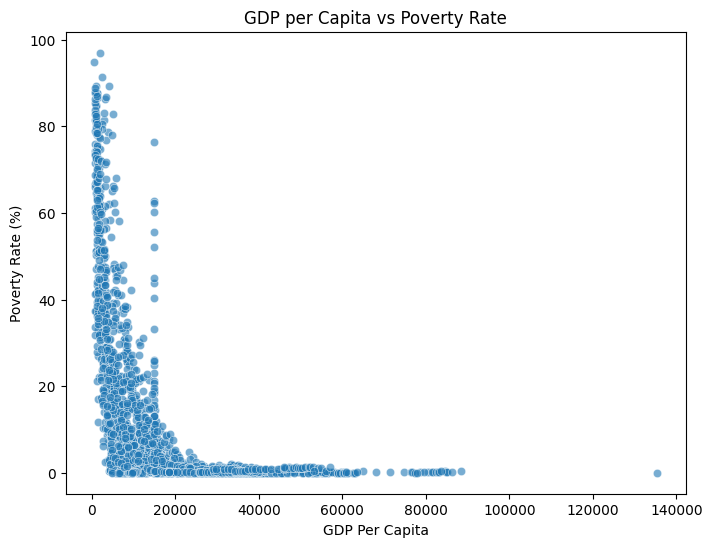

In [54]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="gdp_per_capita", y="poverty_rate", data=cleaned_data, alpha=0.6)
plt.title("GDP per Capita vs Poverty Rate")
plt.xlabel("GDP Per Capita")
plt.ylabel("Poverty Rate (%)")
plt.show()

### GDP Per Capita vs Gini Index

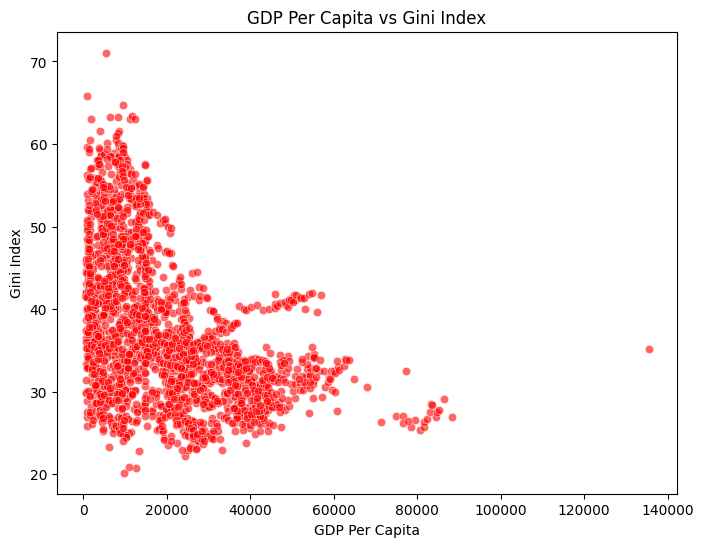

In [55]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="gdp_per_capita", y="gini_index", data=cleaned_data, alpha=0.6, color="red")
plt.title("GDP Per Capita vs Gini Index")
plt.xlabel("GDP Per Capita")
plt.ylabel("Gini Index")
plt.show()

### Gini Index vs Income Top 1%

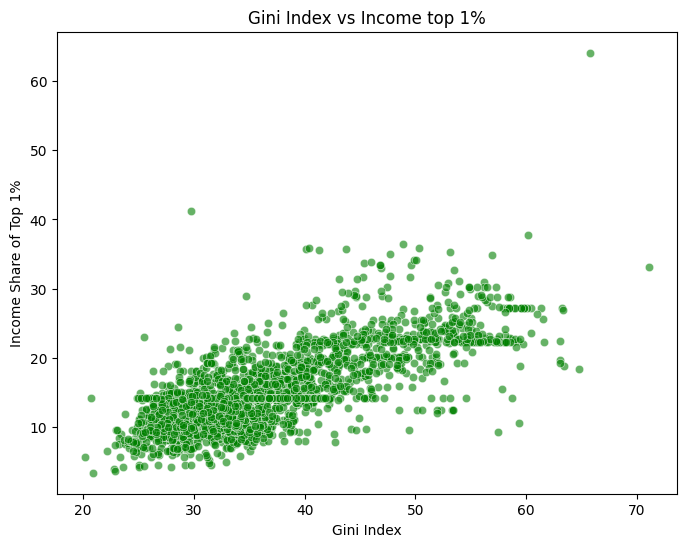

In [56]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="gini_index", y="income_top1", data=cleaned_data, alpha=0.6, color="green")
plt.title("Gini Index vs Income top 1%")
plt.xlabel("Gini Index")
plt.ylabel("Income Share of Top 1%")
plt.show()

### This suggests that in societies where the very wealthy hold a larger slice of the economic pie, the overall level of inequality (measured by the Gini index) tends to be higher.

Text(0.5, 0, 'Gini Index')

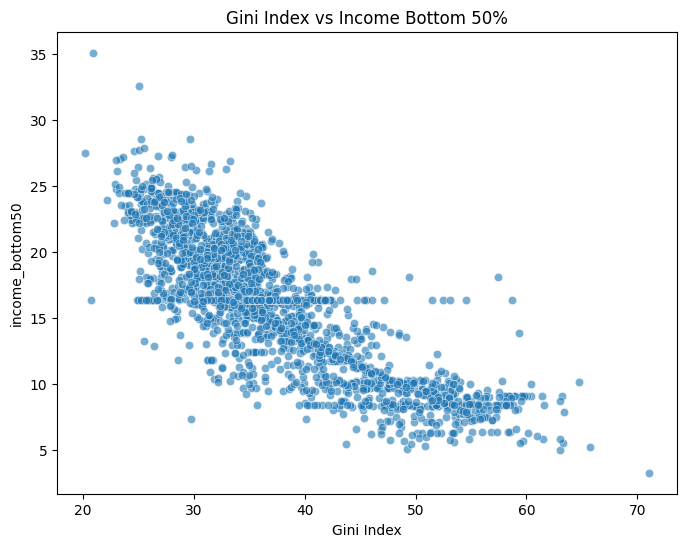

In [62]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="gini_index", y="income_bottom50", data=cleaned_data, alpha=0.6)
plt.title("Gini Index vs Income Bottom 50%")
plt.xlabel("Gini Index")\

### This is known as negative co relation

* As the income of bottom 50% increases Gini index decreases.

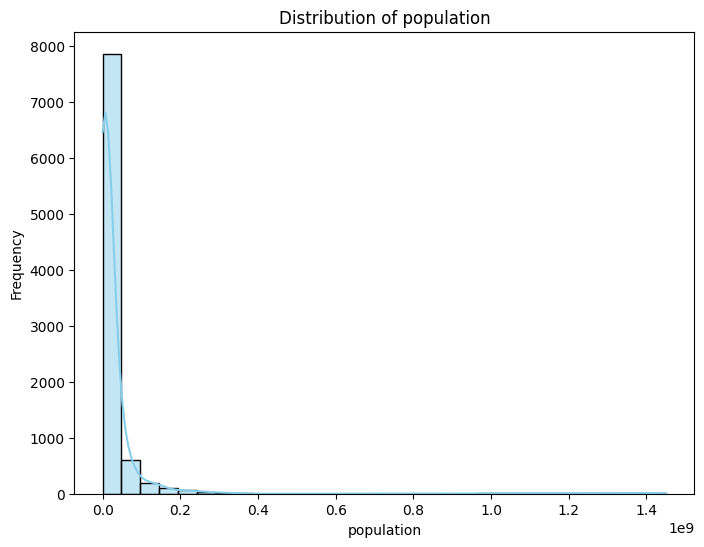

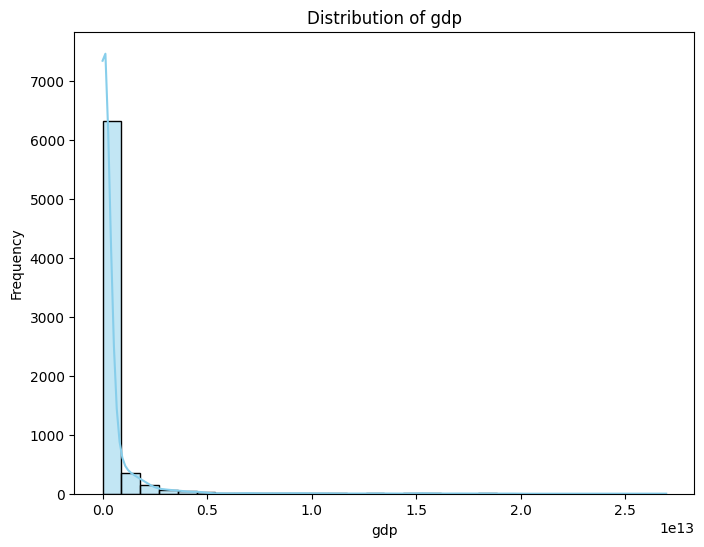

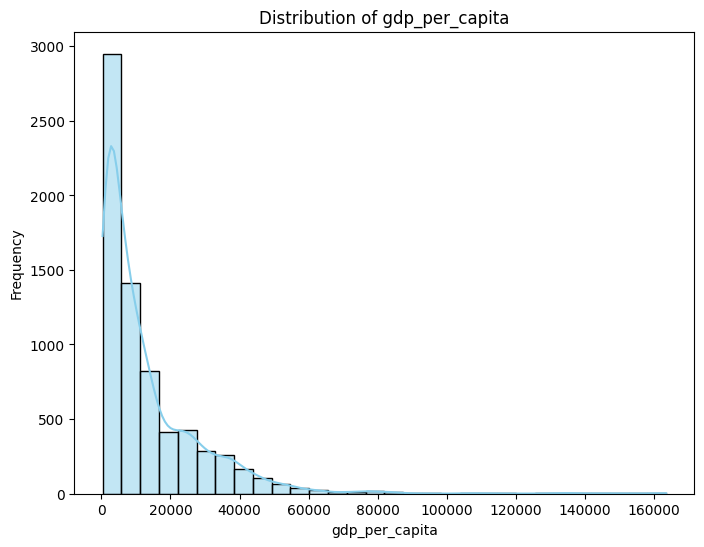

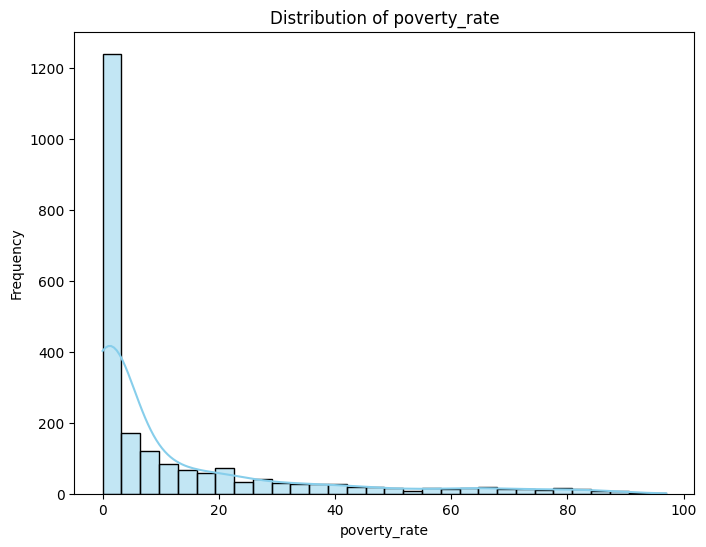

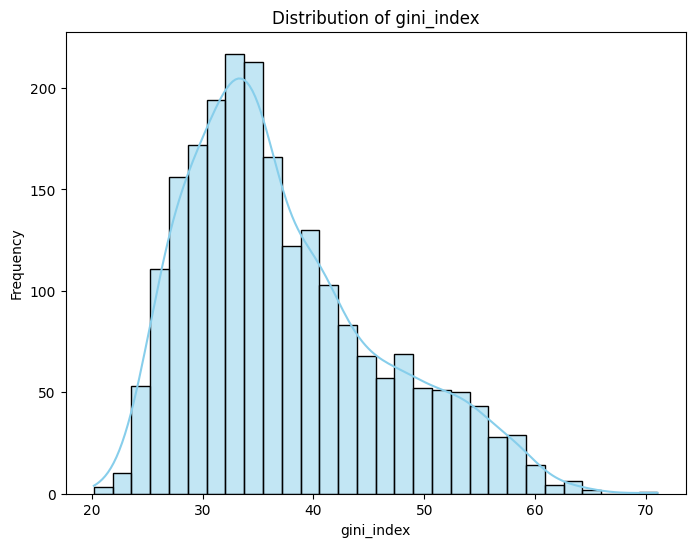

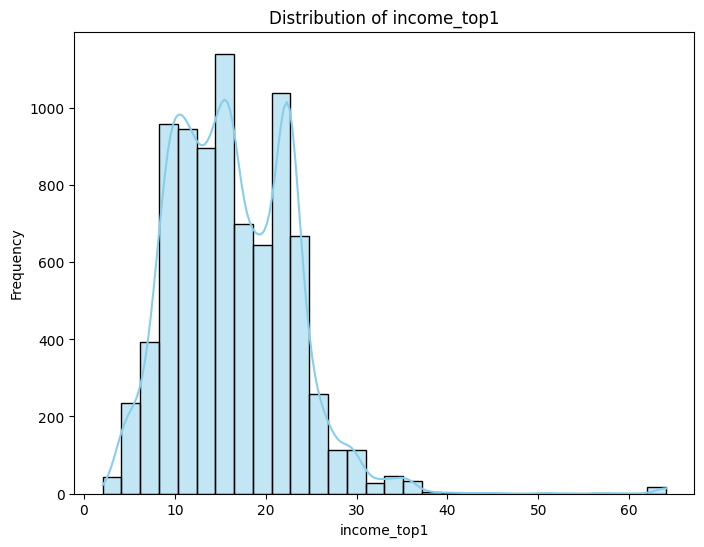

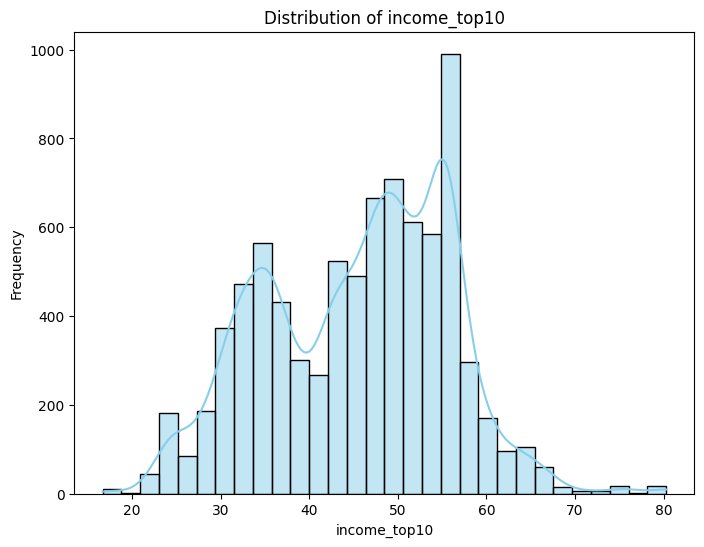

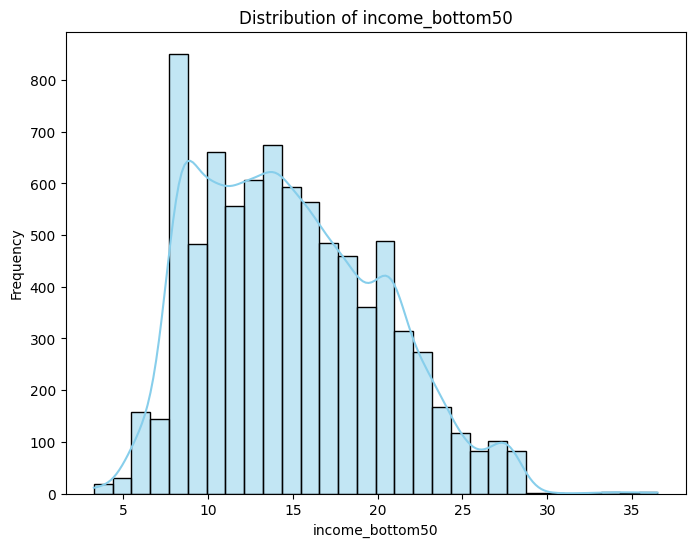

In [63]:
# Step 5: Plot histograms for each numeric column
numeric_cols = ["population","gdp","gdp_per_capita","poverty_rate",
                "gini_index","income_top1","income_top10","income_bottom50"]

for col in numeric_cols:
    plt.figure(figsize=(8,6))
    sns.histplot(data[col], bins=30, kde=True, color="skyblue")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()